In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [4]:
train_data = datagen.flow_from_directory(
    'flowers',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)


Found 1290 images belonging to 2 classes.


In [5]:
val_data = datagen.flow_from_directory(
    'flowers',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)


Found 321 images belonging to 2 classes.


In [6]:
model = Sequential()


In [7]:
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(pool_size=(2,2)))


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

In [9]:
model.add(Flatten())

In [10]:
model.add(Dense(128, activation='relu'))


In [11]:
model.add(Dense(1, activation='sigmoid'))


In [12]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [13]:
history = model.fit(
    train_data,
    epochs=5,
    validation_data=val_data
)

Epoch 1/5
41/41 ━━━━━━━━━━━━━━━━━━━━ 38s 847ms/step - accuracy: 0.5899 - loss: 0.6922 - val_accuracy: 0.6822 - val_loss: 0.5579
Epoch 2/5
41/41 ━━━━━━━━━━━━━━━━━━━━ 16s 379ms/step - accuracy: 0.7403 - loss: 0.5361 - val_accuracy: 0.7196 - val_loss: 0.5305
Epoch 3/5
41/41 ━━━━━━━━━━━━━━━━━━━━ 16s 380ms/step - accuracy: 0.8163 - loss: 0.4143 - val_accuracy: 0.8505 - val_loss: 0.3708
Epoch 4/5
41/41 ━━━━━━━━━━━━━━━━━━━━ 16s 398ms/step - accuracy: 0.8930 - loss: 0.2675 - val_accuracy: 0.8100 - val_loss: 0.4280
Epoch 5/5
41/41 ━━━━━━━━━━━━━━━━━━━━ 16s 384ms/step - accuracy: 0.9310 - loss: 0.1900 - val_accuracy: 0.7726 - val_loss: 0.4885


In [14]:
loss, accuracy = model.evaluate(val_data)

print("Validation Accuracy:", accuracy)


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 156ms/step - accuracy: 0.7726 - loss: 0.4885
Validation Accuracy: 0.7725856900215149


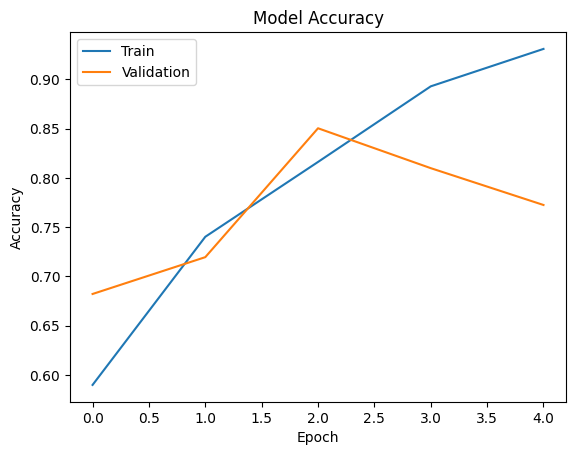

In [15]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()